## <font color='blue'>Projeto:</font>
## <font color='blue'>Análise de Dados de RH (Recursos Humanos)</font>

Neste  projeto  faremos  uma  sequência  completa  de  `análise descritiva,  diagnóstica  e estatística` de dados de RH (Recursos Humanos). Usaremos dados reais disponíveis publicamente e aplicaremos diversas técnicas de análise de dados.

### Definição do problema:

Uma  empresa  de  consultoria que  atua  em  Big  Data  e  Data  Science  deseja  contratar Cientistas de Dados entre pessoas que obtenham aprovação em alguns cursos ministrados pela empresa. Muitas pessoas se inscreveram para o treinamento. A empresa quer saber `quais desses candidatos realmente querem trabalhar para a empresa após o treinamento ou estão apenas fazendo o treinamento para retornarem ao mercado à procura de um novo emprego`. **O objetivo é  contratar  os  profissionais  com  perfil  adequado**, a  fim  de reduzir  o  custo  e  o  tempo de contratação, bem como a qualidade do treinamento ou planejamento dos cursos e categorização dos candidatos. Informações  relacionadas  a  dados  demográficos,  educação e experiência  estão disponíveis no conjunto de dados fornecido.Nosso objetivo será realizar um extenso trabalho de análise nos dados, compreender como  estão  organizados,  realizar  ***limpeza e  transformação***  nos  dados  conforme  necessário, detectar eventuais padrões e diagnósticos e ao final emitir um parecer com um resumo sobre os dados.

### FONTE DOS DADOS:

> https://www.kaggle.com/arashnic/hr-analytics-job-change-of-data-scientistsEste 

- conjunto de dados foi desenvolvido para entender os fatores que levam uma pessoa a deixar o emprego atual. O objetivo do dataset é exatamente fazer pesquisas de RH.

## Dicionário dos dados

**enrollee_id :** ID único do candidato

**city :** Código da cidade

**city_development_index :** Índice de desenvolvimento da cidade (normalizado)

**gender :** Gênero do candidato

**relevent_experience :** Experiência relevante do candidato

**enrolled_university :** Tipo de curso universitário matriculado (se houver)

**education_level :** Nível de escolaridade do candidato

**major_discipline :** Área principal de formação do candidato

**experience :** Experiência total do candidato em anos

**company_size :** Número de funcionários na empresa atual do candidato

**company_type :** Tipo da empresa empregadora atual

**lastnewjob :** Diferença em anos entre o emprego anterior e o atual

**training_hours :** Horas de treinamento concluídas

**target :** 0 – Não está procurando mudança de emprego, 1 – Está procurando mudança de emprego

Analisamos a correlação entre as variaveis numericas, e entre as variaveis numericas e a variavel alvo(target)
O projeto é totalmente orientado a essa variavel alvo(target), como visto na definição do problema
`target indica se o canditado deixou ou não a empresa`

---

## Instalando e Carregando os Pacotes

In [1]:
# Imports

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

## Carregando os Dados

In [2]:
# Carrega o dataset
df = pd.read_csv("aug_train.csv")

In [3]:
# Shape
df.shape

(19158, 14)

In [4]:
# Colunas
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [5]:
# Amostra dos dados
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [6]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

**Obs:** Coluna target não é uma variavel numérica e sim uma variavel categorica onde 1.0 é SIM e 0.0 é NÃO!!! Porem o python reconheceu como float

## Análise Exploratória de Dados

In [7]:
# Descrevendo os dados não numéricos
df.describe(include = object)

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040


In [8]:
# Descrevendo os dados numéricos

df.describe().drop(columns = ['enrollee_id', 'target'])

,city_development_index,training_hours
count,19158.000000,19158.000000
mean,0.828848,65.366896
std,0.123362,60.058462
min,0.448000,1.000000
25%,0.740000,23.000000
50%,0.903000,47.000000
75%,0.920000,88.000000
max,0.949000,336.000000


* Em **city_development_index** (CDI), os valores médios são 0,828, mediana 0,903 e std 0,123. Isso significa que a maioria dos candidatos é de cidades bem desenvolvidas.


* Em **training_hours**, os valores médios são 65,367, mediana 47 e max 336. Isso significa que há mais candidatos com poucas horas de treinamento, mas alguns candidatos gastam muito tempo para fazer o treinamento.

### Visualizando as Variáveis Categóricas

In [9]:
# São as colunas 3 até a 11

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [10]:
list(df.columns.values)[3:12]

['gender',
 'relevent_experience',
 'enrolled_university',
 'education_level',
 'major_discipline',
 'experience',
 'company_size',
 'company_type',
 'last_new_job']

In [11]:
# Vizualizando em Dataframe:

colunas = df.columns[3:12]
df[colunas]

,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
0,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1
1,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4
2,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never
3,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never
4,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4
...,...,...,...,...,...,...,...,...,...
19153,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1
19154,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4
19155,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4
19156,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2


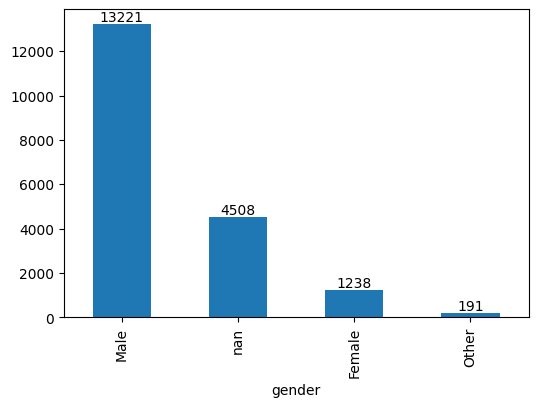

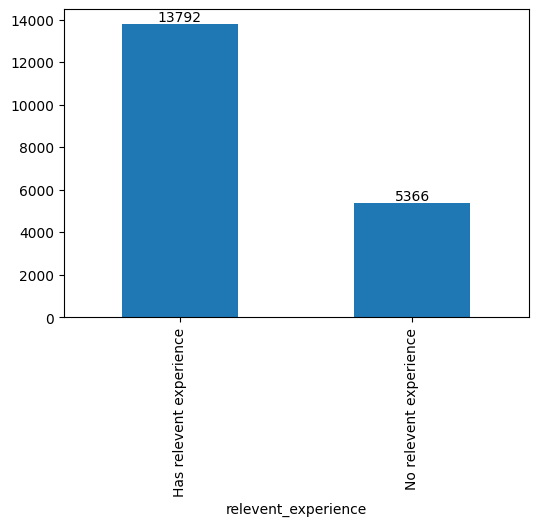

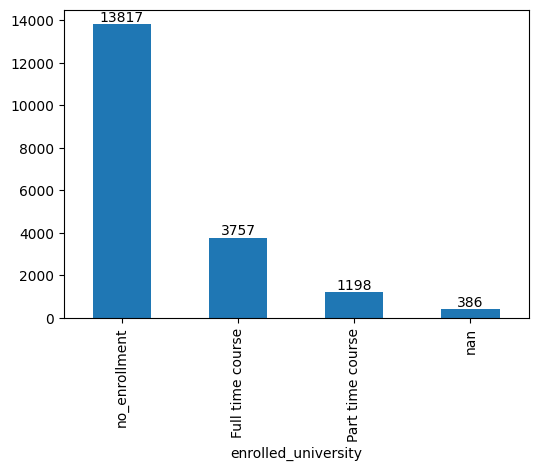

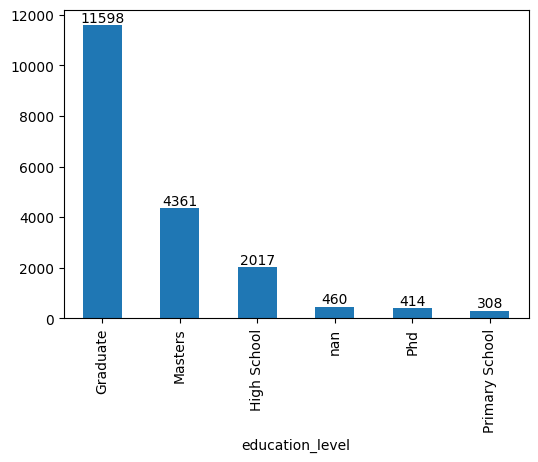

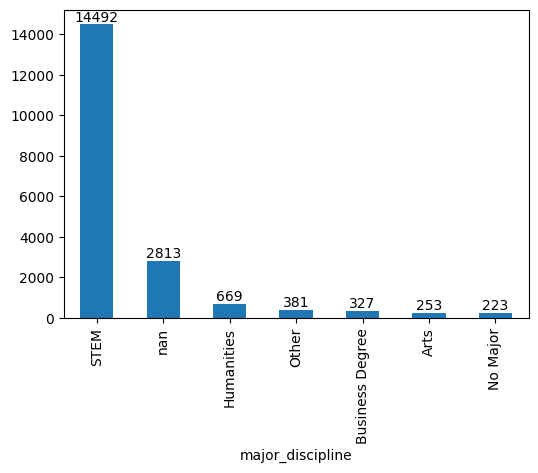

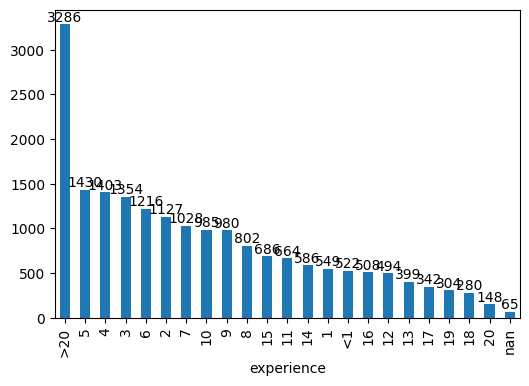

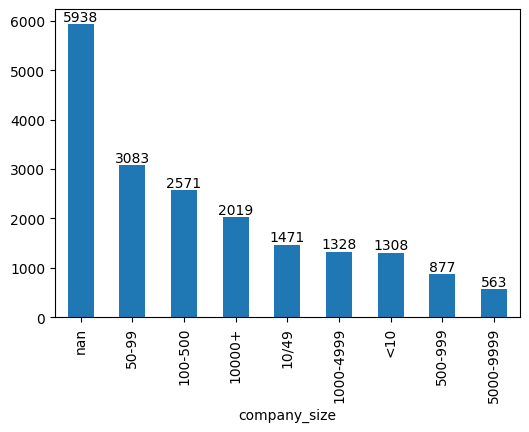

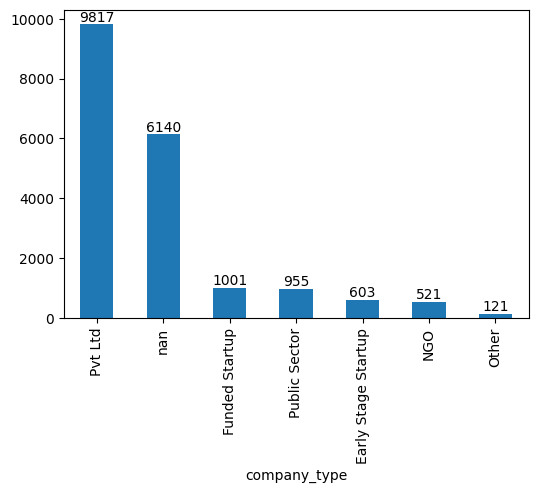

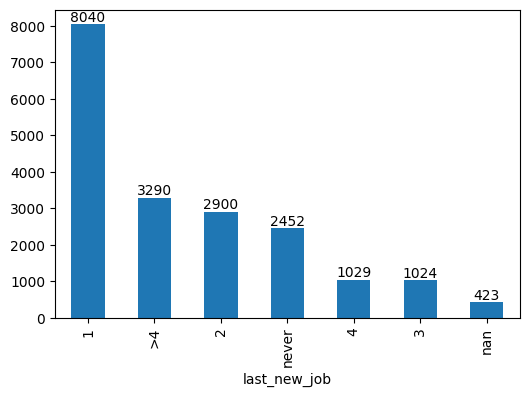

In [23]:
# Visualização gráfica:

for i in df_visualizacao:
    
    ax = df[i].value_counts(dropna=False).plot(kind='bar', figsize=(6, 4))
    ax.bar_label(ax.containers[0])
    
    plt.show()

### Verificando a Distribuição das Variáveis Numéricas

In [12]:
# Descrevendo os dados numéricos
df.describe().drop(columns = ['enrollee_id', 'target'])

,city_development_index,training_hours
count,19158.000000,19158.000000
mean,0.828848,65.366896
std,0.123362,60.058462
min,0.448000,1.000000
25%,0.740000,23.000000
50%,0.903000,47.000000
75%,0.920000,88.000000
max,0.949000,336.000000


Em Estatística, a distribuição normal é uma das distribuições de probabilidade mais utilizadas para modelar fenômenos naturais.

A distribuição normal, também conhecida como distribuição gaussiana, é uma curva simétrica em torno do seu ponto médio, apresentando assim seu famoso formato de sino, o grafico de histograma serve para verificar isso!!!

Uma distribuição estatística é uma função que define uma curva, e a área sob essa curva determina a probabilidade de ocorrer o evento por ela correlacionado.

E o que é distribuição normal? É a mais importante dentre as distribuições estatísticas. A curva de distribuição normal representa o comportamento de diversos processos nas empresas e muitos fenômenos comuns, como por exemplo, altura ou peso de uma população, a pressão sanguínea de um grupo de pessoas, o tempo que um grupo de estudantes gasta para realizar uma prova. A distribuição normal serve também como base para a inferência estatística clássica.

Na distribuição normal, a média, mediana e moda dos dados possuem o mesmo valor.

**Graficos de Histograma com curva de densidade (para verificar se a distribuição esta normal), do CDI e Horas de treinamento(city_development_index e training_hours).**

`Vai ser notado que os graficos não seguem uma distribuição normal!!!!!`

* Histograma com curva de densidade:

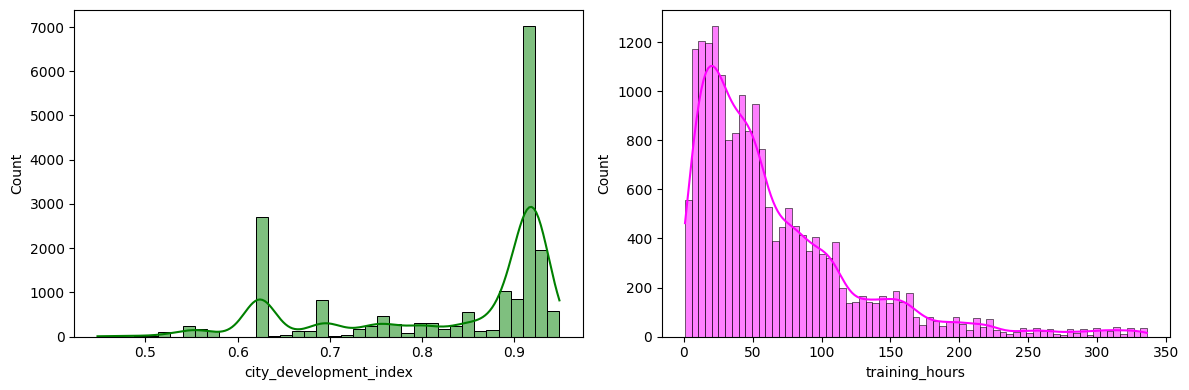

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 1, 2 = 1 linha e 2 colunas

sns.histplot(df['city_development_index'], kde=True, color='green', ax=axes[0])

sns.histplot(df['training_hours'], kde=True, color='magenta', ax=axes[1])

plt.tight_layout() # ajusta os espaçamentos automaticamente
plt.show()

**Obs:** Dependendo de como é a Distribuição será usada uma tecnica diferente

**O Boxplot serve para identificar os valores outliers!!!!!!!!!**

Boxplot feito com as colunas city_development_index e training_hours

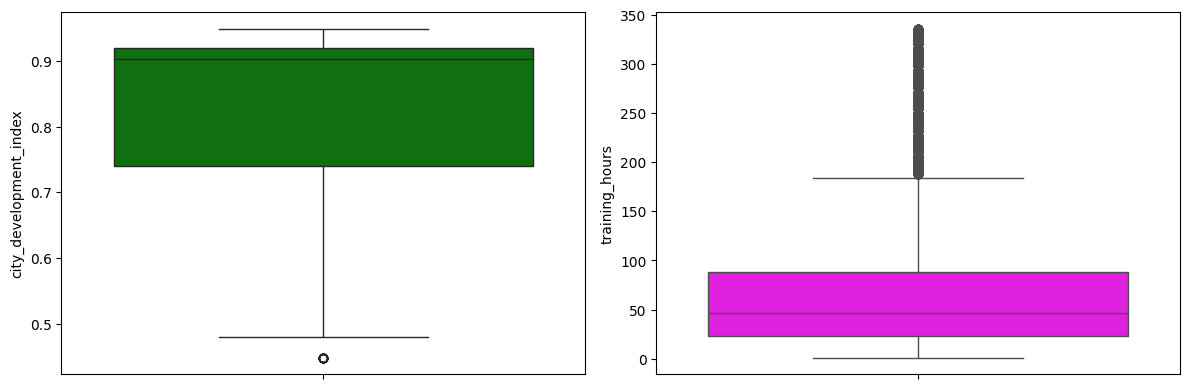

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 1, 2 = 1 linha e 2 colunas

sns.boxplot(df['city_development_index'], color = "green", ax=axes[0])

sns.boxplot(df['training_hours'], color = "magenta", ax=axes[1])

plt.tight_layout() # ajusta os espaçamentos automaticamente
plt.show()

Acima segue o Boxplot dos dados numéricos, onde é notado a presença de valores outliers (os pontos pretos)

A média é sempre influêciada pelos valores outliers, já a mediana(50%) não é influênciada

**Teste de normalidade da distribuição:**
        
* normaltest aplica um teste de hipótese que valida a normalidade da variação

* stats retorna a estatistica/ pval retorna o valor P

In [ ]:
import scipy
from scipy.stats import normaltest

In [19]:
# Teste de Normalidade da Distribuição

# Lista com as variáveis numéricas
numerical_feature = ['city_development_index', 'training_hours']

# Loop
for i in numerical_feature:
    
    # Calcula a normalidade
    stats, pval = normaltest(df[i])
    
     # Checar valor-p
    if pval > 0.05:
        print(i, ': Distribuição Normal')
    else:
        print(i, ': Distribuição Não Normal')

city_development_index : Distribuição Não Normal
training_hours : Distribuição Não Normal


* As variáveis **city_development_index** e **training_hours** não seguem a distribuição normal. Para a análise numérica, usaremos o método não paramétrico.


* Dados de **training_hours** estão localizados principalmente no lado esquerdo do histograma. É um comportamento esperado porque as pessoas geralmente ficam animadas ao fazer o treinamento no início, mas nem todos que começam conseguem terminar uma maratona. ;-)

### Correlação dos Dados

#### Correlação de Spearman Entre Variáveis Numéricas

Analisamos a correlação entre as variáveis numéricas e entre as variáveis numéricas e a variável alvo (o que estamos querendo analisar).

In [16]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [17]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [18]:
# Criamos uma cópia do dataframe original
df_numerical = df.copy()

In [19]:
df_numerical["experience"].value_counts()

experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
Name: count, dtype: int64

**Tratando os valores: >20 e <1 da coluna 'experience'**

In [21]:
# Convertemos a variável experience para numérica

df_numerical['experience'] = np.where(df_numerical['experience'] == '<1', 1, df_numerical['experience'])
df_numerical['experience'] = np.where(df_numerical['experience'] == '>20', 21, df_numerical['experience'])
#df_numerical['experience'] = np.array(df_numerical['experience'], dtype=float) # Tranformando os valores em float
df_numerical['experience'] = df_numerical['experience'].astype(float)

#df_numerical['experience'] = np.where(df_numerical['experience'] == '<1', 1, np.where(df_numerico['experience'] == '>20', 20, df_numerical['experience']))

In [22]:
df_numerical["experience"].value_counts()

experience
21.0    3286
5.0     1430
4.0     1403
3.0     1354
6.0     1216
2.0     1127
1.0     1071
7.0     1028
10.0     985
9.0      980
8.0      802
15.0     686
11.0     664
14.0     586
16.0     508
12.0     494
13.0     399
17.0     342
19.0     304
18.0     280
20.0     148
Name: count, dtype: int64

**Coluna: last_new_job para tratar os dados:**

In [23]:
df_numerical["last_new_job"].value_counts()

last_new_job
1        8040
>4       3290
2        2900
never    2452
4        1029
3        1024
Name: count, dtype: int64

In [24]:
# Convertemos a variável last_new_job para numérica

df_numerical["last_new_job"] = np.where(df_numerical["last_new_job"] == "never", 0, df_numerical["last_new_job"])
df_numerical["last_new_job"] = np.where(df_numerical["last_new_job"] == ">4", 5, df_numerical["last_new_job"])
df_numerical["last_new_job"] = df_numerical["last_new_job"].astype(float)

In [25]:
df_numerical["last_new_job"].value_counts()

last_new_job
1.0    8040
5.0    3290
2.0    2900
0.0    2452
4.0    1029
3.0    1024
Name: count, dtype: int64

In [27]:
# Verificando o tratamento das colunas `'experience' e 'last_new_job'`

df_numerical.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,NaN,NaN,1.0,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,5.0,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,0.0,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,1.0,NaN,Pvt Ltd,0.0,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,50-99,Funded Startup,4.0,8,0.0


In [28]:
df_numerical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  float64
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(4), int64(2), object(8)
mem

**Correlação de spearman entre variáveis numéricas:**

* mede a relação MONÓTONA entre duas variáveis.

👉 Em termos simples:

`Ela mede se duas variáveis “sobem ou descem juntas”, independentemente da forma da relação.`

* Uma relação é monótona quando:

À medida que X aumenta:

Y sempre aumenta (monótona crescente) 📈

ou Y sempre diminui (monótona decrescente) 📉

>metodo corr tenta desconsiderar variaveis do tipo object
>
>Porém ele quebra quando encontra strings como 'city_103' por isso usaremo: .select_dtypes(include="number")

In [31]:
#df_numerical.drop("enrollee_id", axis = 1).corr("spearman")

df_numerical.drop("enrollee_id", axis=1).select_dtypes(include="number").corr("spearman") # metodo corr já tenta desconsiderar variaveis do tipo object

,city_development_index,experience,last_new_job,training_hours,target
city_development_index,1.000000,0.300997,0.182698,0.007491,-0.279165
experience,0.300997,1.000000,0.473284,0.003569,-0.183721
last_new_job,0.182698,0.473284,1.000000,0.002959,-0.082045
training_hours,0.007491,0.003569,0.002959,1.000000,-0.014126
target,-0.279165,-0.183721,-0.082045,-0.014126,1.000000


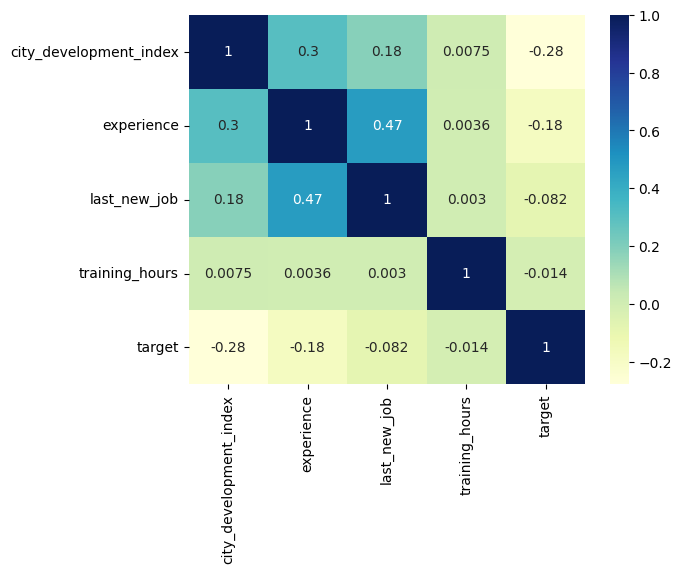

In [33]:
# Heatmap

# annot=True → mostra os valores numéricos dentro das células

# cmap='YlGnBu' → paleta de cores (amarelo → verde → azul)

sns.heatmap(df_numerical.drop("enrollee_id", axis=1).select_dtypes(include="number").corr("spearman"), annot=True, cmap='YlGnBu')
plt.show()

Pela correlação de spearman, last_new_job e experience têm correlação média (0,473), enquanto outros têm correlação fraca.

As variáveis last_new_job e training_hours tem correlação próxima de zero com a variável alvo e poderiam ser descartadas.

Para a relação entre as variáveis categóricas e a variável alvo, usaremos WOE e IV.

### Weight of Evidence (WOE) e Information Value (IV)

Este conjunto de dados contém mais dados com tipo categórico do que tipo numérico. Usaremos recursos categóricos nominais para WOE e IV.

Interpretamos o resultado de IV assim:

    Information Value, Poder de Previsão
    
    < 0.02, não deve ser usado para previsão
    0.02 - 0.1, preditor fraco
    0.1 - 0.3, preditor médio
    0.3 - 0.5, preditor forte
    > 0.5, parece bom demais para ser verdade

In [34]:
colunas_categoricas = ['enrolled_university', 'relevent_experience', 'education_level', 'company_type', 'major_discipline','gender']

**Importar o módulo pronto com a função:**

**`Importando o módulo pronto:`**

>>`import os`
>>
>>`import sys`
>>
>>`sys.path.append(os.path.abspath(os.path.join("Modulos")))`
>>
>>`from woe_iv_variavel_categ import *`

In [39]:
import os
import sys

sys.path.append(os.path.abspath(os.path.join("Modulos")))

from woe_iv_variavel_categ import *

**Criando a Função:**

In [35]:
def calcula_iv_categoricas(
    df,
    target,
    *colunas,
    show_plot=True,      # 👈 gráfico aparece por padrão
    return_df=False,     # 👈 DataFrame NÃO aparece por padrão
    figsize=(10, 12),
    eps=1e-6
):
    """
    Calcula o Information Value (IV) para variáveis categóricas.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame com os dados

    target : str
        Nome da variável alvo (binária: 0 e 1)

    colunas : str ou list
        Nomes das colunas categóricas

    show_plot : bool, default=True
        Se True, exibe o gráfico

    return_df : bool, default=False
        Se True, retorna o DataFrame com os IVs

    figsize : tuple
        Tamanho da figura

    eps : float
        Valor pequeno para evitar divisão por zero
    """

    # 🔹 Normaliza entrada (lista + argumentos)
    colunas_cat = []
    for col in colunas:
        if isinstance(col, (list, tuple, set)):
            colunas_cat.extend(col)
        else:
            colunas_cat.append(col)

    colunas_cat = list(dict.fromkeys(colunas_cat))  # remove duplicados

    iv_list = []

    for col in colunas_cat:
        tabela = pd.crosstab(
            df[col],
            df[target],
            normalize='columns'
        )

        tabela['woe'] = np.log((tabela[1] + eps) / (tabela[0] + eps))
        iv = np.sum(tabela['woe'] * (tabela[1] - tabela[0]))

        iv_list.append(iv)

    df_iv = (
        pd.DataFrame({
            'Feature': colunas_cat,
            'IV': iv_list
        })
        .set_index('Feature')
        .sort_values(by='IV')
    )

    # 🔹 Gráfico (opcional, default ON)
    if show_plot:
        plt.figure(figsize=figsize)
        df_iv.plot(
            kind='barh',
            title='Information Value das Variáveis Categóricas',
            colormap='Accent',
            legend=False
        )

        for idx, val in enumerate(round(df_iv['IV'], 3)):
            plt.text(val, idx, str(val))

        plt.show()

    # 🔹 DataFrame (opcional, default OFF)
    if return_df:
        return df_iv

<Figure size 1000x1200 with 0 Axes>

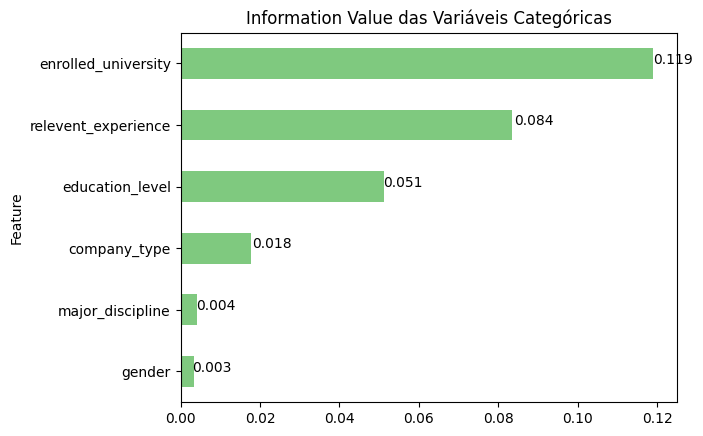

In [40]:
calcula_iv_categoricas(df_numerical, 'target', colunas_categoricas)

No gráfico acima, podemos ver a ordem dos recursos com base em seu poder preditivo em relação ao alvo target.
Com base em seu valor IV, enrolled_university é um preditor médio, relevent_experience e education_level são preditores fracos e os outros são inúteis para a previsão.

### Identificando Valores Ausentes

In [44]:
# Valores ausentes por coluna

null_df = df.isna().sum()
#null_df = df.isna().sum().reset_index() # Formato dataframe
null_df

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

### Identificando Valores Duplicados

In [46]:
# Checando valores duplicados (não há)

df['enrollee_id'].duplicated().sum()

np.int64(0)

### LIMPEZA E TRATAMENTO DOS DADOS

### Tratando os Valores Ausentes

In [48]:
df.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

As Colunas numericas serão mantidas com criterio de correção maior com a variavel target

O restante das colunas categoricas foi mantida e retirada a cidade e o Id ('enrollee_id', 'city')

A variavel 'company_size', já não estava sendo considerada nas analises e tambem foi retirada

RESUMINDO: Foram mantidas as colunas com maior correlação do mapa de calor e as colunas com maior relação do grafico de IV

In [49]:
colunas_manter = ['city_development_index', 
                  'experience', 
                  'enrolled_university', 
                  'relevent_experience', 
                  'education_level',
                  'company_type',
                  'major_discipline',
                  'target']

In [50]:
new_df = df[colunas_manter]

In [51]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,>20,no_enrollment,Has relevent experience,Graduate,NaN,STEM,1.0
1,0.776,15,no_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5,Full time course,No relevent experience,Graduate,NaN,STEM,0.0
3,0.789,<1,NaN,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,>20,no_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


In [52]:
# Visualizar o dataframe original

# df.head()

In [53]:
# Verificando os valores ausentes do novo df (new_df)

null_df = new_df.isna().sum().reset_index() #.to_frame()
null_df

,index,0
0,city_development_index,0
1,experience,65
2,enrolled_university,386
3,relevent_experience,0
4,education_level,460
5,company_type,6140
6,major_discipline,2813
7,target,0


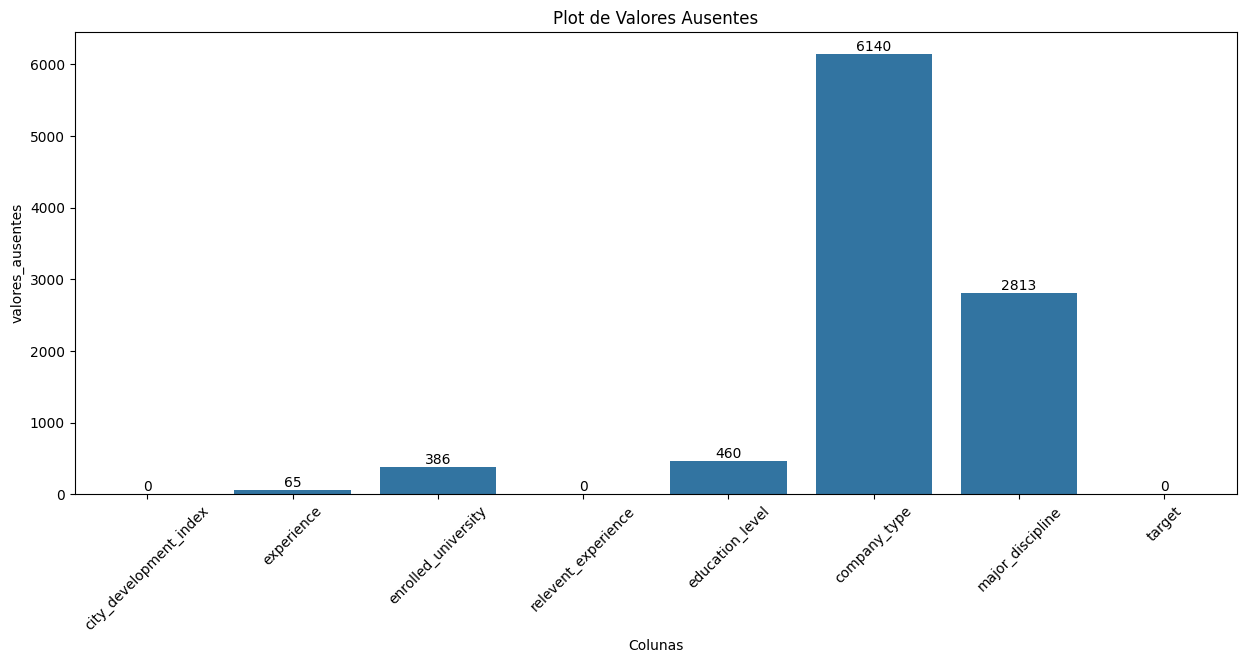

In [54]:
# Renomear colunas de null_df para facilitar
# null_df.columns = ['colunas', 'valores_ausentes']

# Criar gráfico
plt.figure(figsize=(15,6))
ax = sns.barplot(data=null_df, x='index', y=0) # pode ser incluido palette=cores (cores ao grafico)

# Adicionar título e rótulos
plt.title('Plot de Valores Ausentes')
plt.xlabel('Colunas')
plt.ylabel('valores_ausentes')

# Girar labels do eixo x se necessário (nomes das colunas 45°)
plt.xticks(rotation=45)

# Adicionar valores no topo das barras
ax.bar_label(ax.containers[0])

# Mostrar gráfico
plt.show()

#### Variável major_discipline

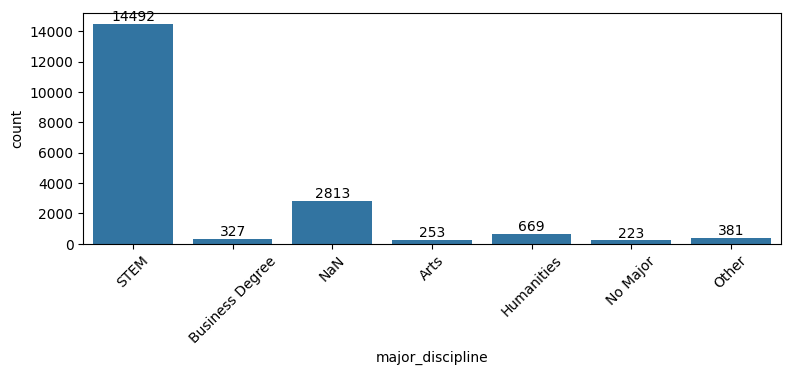

In [56]:
# Valores Ausentes da Variável major_discipline Antes do Processamento
plt.figure(figsize= (9, 3))

ax = sns.countplot(data=new_df.fillna('NaN'), x='major_discipline')

ax.bar_label(ax.containers[0])
# Girar labels do eixo x se necessário (nomes das colunas 45°)
plt.xticks(rotation=45)
    
plt.show()

In [57]:
# Visualizando sem o grafico

new_df['major_discipline'].value_counts(dropna=False)

major_discipline
STEM               14492
NaN                 2813
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

**Como está a proporção de NaN(2813) de major_discipline na variavel education_level?**

In [58]:
# Relação entre major_discipline x education_level
print('\nTotal de Valores Ausentes na Variável major_discipline:', new_df['major_discipline'].isna().sum())
print('\nProporção de Valores Ausentes na Variável education_level:')

new_df[new_df['major_discipline'].isna()]['education_level'].value_counts(dropna=False)


Total de Valores Ausentes na Variável major_discipline: 2813

Proporção de Valores Ausentes na Variável education_level:


education_level
High School       2017
NaN                460
Primary School     308
Graduate            22
Masters              6
Name: count, dtype: int64

Dentre os registros com valores ausentes, vemos a proporção na variável education_level.

Preencheremos os valores NA da variável `major_discipline` com `Non Degree`.

In [59]:
# Cria o índice
#nan_index = (new_df[(new_df['major_discipline'].isna()) & ((new_df['education_level']=='High School') | (new_df['education_level'].isna()) | (new_df['education_level']=='Primary School'))]).index

index = (new_df['major_discipline'].isna() & (new_df['education_level'].isin(['Primary School', 'High School']) | new_df['education_level'].isna()))

In [61]:
# Substituindo as linhas(index) na coluna major_discipline para 'Sem Formacao'

new_df.loc[index, 'major_discipline'] = 'Sem Formacao'

In [63]:
# Visualizando o resultado:

print('Total de Valores Ausentes na Variável major_discipline:', new_df['major_discipline'].isna().sum())
new_df['major_discipline'].value_counts(dropna = False)

new_df['major_discipline'].value_counts(dropna=False)

Total de Valores Ausentes na Variável major_discipline: 28


major_discipline
STEM               14492
Sem Formacao        2785
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
NaN                   28
Name: count, dtype: int64

In [64]:
# Verificando a quantidade de valores nulos

new_df['major_discipline'].isna().sum()

np.int64(28)

**Fazendo a imputação:**

In [65]:
# Para os valores ausentes restantes preenchemos com 'Other'

new_df.loc[new_df['major_discipline'].isna() & new_df['education_level'].isin(['Graduate', 'Masters']), 'major_discipline'] = 'Other'

In [66]:
# Verificando os valores unicos após tratado

new_df['major_discipline'].value_counts(dropna=False)

major_discipline
STEM               14492
Sem Formacao        2785
Humanities           669
Other                409
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

In [67]:
# Verificando a quantidade de valores nulos

new_df['major_discipline'].isna().sum()

np.int64(0)

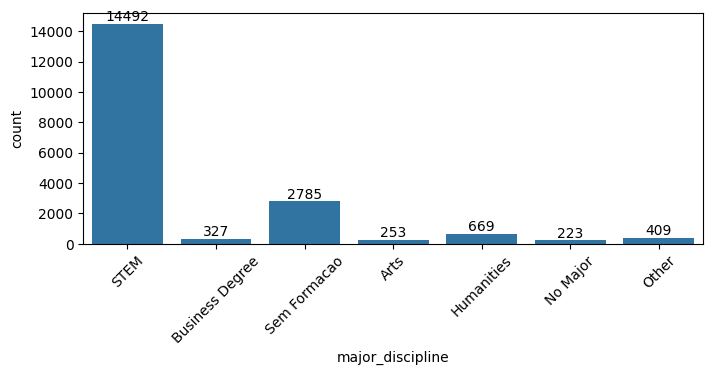

In [68]:
# Valores Ausentes da Variável major_discipline Após o Processamento
plt.figure(figsize=(8,3))

ax = sns.countplot(data=new_df, x='major_discipline')

ax.bar_label(ax.containers[0]) # Por os valores nas barras
plt.xticks(rotation=45) # Rotacionar 45 graus

plt.show()

In [69]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,>20,no_enrollment,Has relevent experience,Graduate,NaN,STEM,1.0
1,0.776,15,no_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5,Full time course,No relevent experience,Graduate,NaN,STEM,0.0
3,0.789,<1,NaN,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,>20,no_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


#### Variável enrolled_university

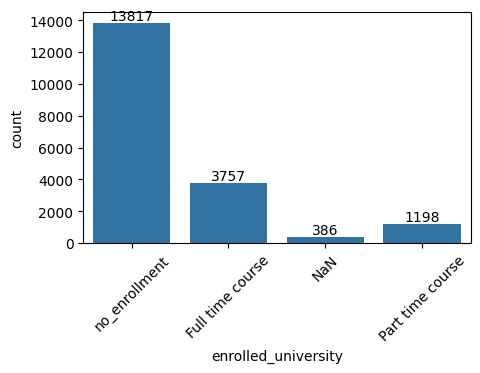

In [70]:
# Gráfico
plt.figure(figsize=(5,3))

ax = sns.countplot(data=new_df.fillna('NaN'), x='enrolled_university')

ax.bar_label(ax.containers[0]) # Incluir os valores nas barras
plt.xticks(rotation=45) # Rotacionar 45 graus os labels

plt.show()

In [72]:
# Verificando os valores unicos, SEM GRÁFICO

new_df['enrolled_university'].value_counts(dropna=False)

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
NaN                   386
Name: count, dtype: int64

In [71]:
print('\nTotal de Valores Ausentes na Variável enrolled_university:', new_df['enrolled_university'].isna().sum())
print('\nProporção de Valores Ausentes na Variável education_level:')
new_df[new_df['enrolled_university'].isna()]['education_level'].value_counts(dropna = False)


Total de Valores Ausentes na Variável enrolled_university: 386

Proporção de Valores Ausentes na Variável education_level:


education_level
Graduate          171
NaN               100
Masters            53
High School        47
Primary School      9
Phd                 6
Name: count, dtype: int64

Candidatos com `Primary School` como `education_level` não estão qualificados para ingressar na universidade. Portanto, preencheremos valores `NaN` em `education_level` para `Primary Grad`.

In [73]:
# Prepara o índice

nan_index = (new_df[(new_df['enrolled_university'].isna()) & (new_df['education_level']=='Primary School')]).index

In [74]:
len(nan_index)

9

In [75]:
# Imputação de valores ausentes

# new_df['enrolled_university'][nan_index] = 'Primary Grad'

new_df.loc[nan_index, 'enrolled_university'] = 'Primary Grad'

In [76]:
# Consultando a mudaça

new_df[new_df['enrolled_university'].isna()]['education_level'].value_counts(dropna=False)

education_level
Graduate       171
NaN            100
Masters         53
High School     47
Phd              6
Name: count, dtype: int64

In [77]:
new_df['enrolled_university'].value_counts(dropna=False)

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
NaN                   377
Primary Grad            9
Name: count, dtype: int64

Resultado: **Foram pegues os valores** `'Primary School' (9 valores) de education_level` e colocados em `'Primary Grad' em enrolled_university`

**Tratando valores ausentes (NaN):**

>>Tratando valores ausentes (NaN)
>>
>>**valores NaN que vão virar 'Other'**

In [79]:
# Total de valores ausentes

new_df['enrolled_university'].isna().sum()

np.int64(377)

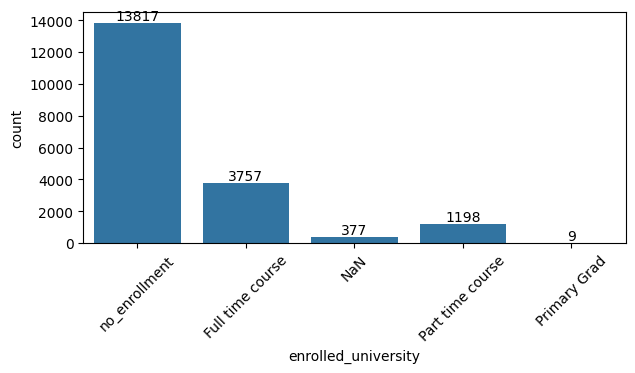

In [80]:
plt.figure(figsize=(7,3))

ax= sns.countplot(data=new_df.fillna('NaN'), x= 'enrolled_university')

ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)

plt.show()

In [81]:
# Prepara o índice

index = new_df[(new_df['enrolled_university'].isna())].index

In [82]:
# O restante colocamos como 'Other'

new_df.loc[index, 'enrolled_university'] = 'Other'

**Resultado:**

In [83]:
# Total de valores ausentes

new_df['enrolled_university'].isna().sum()

np.int64(0)

In [84]:
new_df['enrolled_university'].value_counts(dropna=False)

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Other                 377
Primary Grad            9
Name: count, dtype: int64

Resultado: Os valores de Primary School em education_level foram para Primary Grad em enrolled_university e os valores nulos viraram Other

#### Variável company_type

In [85]:
# Verificando valores unicos

new_df['company_type'].value_counts(dropna=False)

company_type
Pvt Ltd                9817
NaN                    6140
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

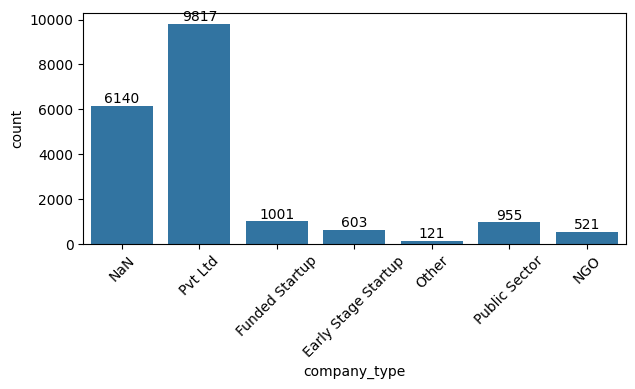

In [86]:
plt.figure(figsize=(7,3))

ax= sns.countplot(data= new_df.fillna('NaN'), x= 'company_type')

ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)

plt.show()

NaN tem o segundo maior numero com 6140, Sempre verificar se tem a informação associada a outra variável, como estava sendo feito antes!!!

Porem, não tem nenhuma informação!!!

In [87]:
# Índice

index = new_df[(new_df['company_type'].isna())].index

In [88]:
# Imputação dos valores NaN com 'Other'

new_df.loc[index, 'company_type'] = 'Other'

In [89]:
# Resultado:

new_df['company_type'].value_counts(dropna=False)

company_type
Pvt Ltd                9817
Other                  6261
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Name: count, dtype: int64

Resultado: Other ja tinha 121 registros e foi somado 6140 de NaN

In [90]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,>20,no_enrollment,Has relevent experience,Graduate,Other,STEM,1.0
1,0.776,15,no_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5,Full time course,No relevent experience,Graduate,Other,STEM,0.0
3,0.789,<1,Other,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,>20,no_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


#### Variável education_level

In [91]:
new_df['education_level'].value_counts(dropna=False)

education_level
Graduate          11598
Masters            4361
High School        2017
NaN                 460
Phd                 414
Primary School      308
Name: count, dtype: int64

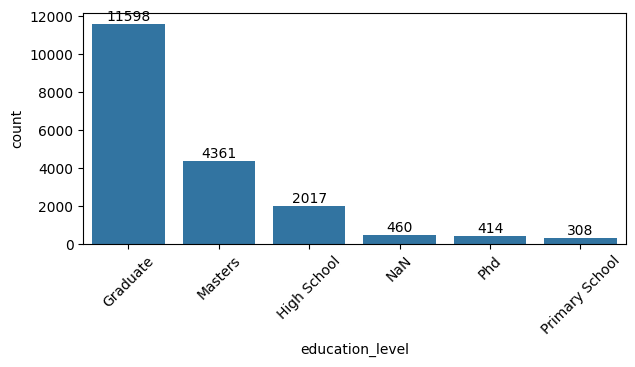

In [92]:
plt.figure(figsize=(7,3))

ax= sns.countplot(data= new_df.fillna('NaN'), x= 'education_level')

ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)

plt.show()

* **Usaremos o fillna()**

In [94]:
new_df.loc[:, 'education_level'] = new_df['education_level'].fillna('Other')

In [95]:
# Conferindo o resultado dos VALORES UNICOS:

new_df['education_level'].value_counts(dropna=False)

education_level
Graduate          11598
Masters            4361
High School        2017
Other               460
Phd                 414
Primary School      308
Name: count, dtype: int64

Resultado: NaN virou Other

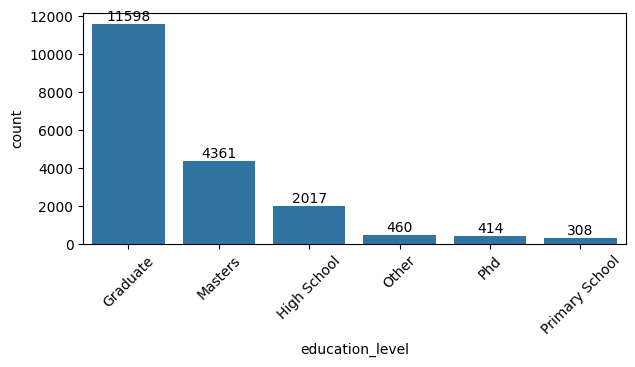

In [96]:
# Visualizando o resultado

plt.figure(figsize=(7,3))

ax = sns.countplot(data= new_df.fillna('NaN'), x= 'education_level')

ax.bar_label(ax.containers[0])
plt.xticks(rotation=45)

plt.show()

In [97]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,>20,no_enrollment,Has relevent experience,Graduate,Other,STEM,1.0
1,0.776,15,no_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5,Full time course,No relevent experience,Graduate,Other,STEM,0.0
3,0.789,<1,Other,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,>20,no_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


#### Variável experience

In [98]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_development_index  19158 non-null  float64
 1   experience              19093 non-null  object 
 2   enrolled_university     19158 non-null  object 
 3   relevent_experience     19158 non-null  object 
 4   education_level         19158 non-null  object 
 5   company_type            19158 non-null  object 
 6   major_discipline        19158 non-null  object 
 7   target                  19158 non-null  float64
dtypes: float64(2), object(6)
memory usage: 1.2+ MB


In [99]:
new_df['experience'].value_counts(dropna=False)

experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
NaN      65
Name: count, dtype: int64

#### Obs: A variável já havia sido tratada antes

In [102]:
#df_numerical['experience'].value_counts(dropna=False)

In [110]:
# Tratando e Convertemos a variável experience para numérica

new_df['experience'] = np.where(new_df['experience'] == '<1', 1, new_df['experience'])
new_df['experience'] = np.where(new_df['experience'] == '>20', 21, new_df['experience'])
#new_df['experience'] = np.array(new_df['experience'], dtype=float) # Tranformando os valores em float
new_df['experience'] = new_df['experience'].astype(float)

#new_df['experience'] = np.where(new_df['experience'] == '<1', 1, np.where(new_df['experience'] == '>20', 20, new_df['experience']))

**Obs:** A porcentagem de valores ausentes em 'experience' é muito pouca (0.33%) e nem compesa tratar, é melhor excluir os valores¶

***`Variaveis com menos de 2% de valores ausentes é melhor deletar`***

In [103]:
# Percentual de valores ausentes

porcentagem_ausente = new_df.isnull().sum() / len(new_df) * 100
porcentagem_ausente

city_development_index    0.000000
experience                0.339284
enrolled_university       0.000000
relevent_experience       0.000000
education_level           0.000000
company_type              0.000000
major_discipline          0.000000
target                    0.000000
dtype: float64

In [104]:
new_df['experience'].isna().sum()

np.int64(65)

In [105]:
new_df.shape

(19158, 8)

In [106]:
# apagando os valores NaN

new_df = new_df.dropna(subset=['experience'])

In [107]:
new_df.shape

(19093, 8)

**Verificando os valores ausentes depois do tratamento com dropna()**

In [108]:
porcentagem_ausente = new_df.isnull().sum() / len(new_df) * 100
porcentagem_ausente

city_development_index    0.0
experience                0.0
enrolled_university       0.0
relevent_experience       0.0
education_level           0.0
company_type              0.0
major_discipline          0.0
target                    0.0
dtype: float64

In [111]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,21.0,no_enrollment,Has relevent experience,Graduate,Other,STEM,1.0
1,0.776,15.0,no_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5.0,Full time course,No relevent experience,Graduate,Other,STEM,0.0
3,0.789,1.0,Other,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,21.0,no_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


### Ajustes Finais

`Ajustes finais em 'enrolled_university': no_enrollment está começando com letra minuscula`

In [112]:
# Ajustando os dados

new_df.loc[:, 'enrolled_university'] = (new_df['enrolled_university'].replace('no_enrollment', 'No_enrollment'))

In [113]:
new_df.head()

,city_development_index,experience,enrolled_university,relevent_experience,education_level,company_type,major_discipline,target
0,0.920,21.0,No_enrollment,Has relevent experience,Graduate,Other,STEM,1.0
1,0.776,15.0,No_enrollment,No relevent experience,Graduate,Pvt Ltd,STEM,0.0
2,0.624,5.0,Full time course,No relevent experience,Graduate,Other,STEM,0.0
3,0.789,1.0,Other,No relevent experience,Graduate,Pvt Ltd,Business Degree,1.0
4,0.767,21.0,No_enrollment,Has relevent experience,Masters,Funded Startup,STEM,0.0


In [114]:
x = new_df.drop(columns = ['target'])

y = new_df['target']

## Relatório Final

**Com base em nossa análise observamos que as variáveis mais relevantes para identificar um bom candidato são:**

- Índice de Desenvolvimento da cidade onde mora o candidato.
- Tempo de experiência profissional.
- Se está ou não matriculado em um curso universitário.
- Se tem ou não experiência relevante.
- O nível educacional.
- O tipo de empresa que o candidato trabalhou ou trabalha atualmente.
- A especialização na graduação (quando for o caso).

**Não são relevantes para a análise:**

- O ID do candidato.
- O código da cidade do candidato.
- O gênero.
- A última vez que o candidato esteve empregado.
- O tamanho da empresa (quando for o caso).
- Total de horas de treimamento.


**Recomendações do Analista de Dados**:

- O RH pode desenvolver um método de coleta de dados para obter outros recursos a fim de melhorar a qualidade dos dados e tornar o trabalho de análise mais preciso.

- *O RH pode procurar candidatos que vêm de cidades com índice de desenvolvimento urbano mais baixo, sem experiência relevante, nível de educação superior e menor experiência de trabalho para ter maior chance de encontrar candidatos que estão procurando um emprego.*

- *O RH pode tornar o treinamento mais compacto porque muitas pessoas não precisam de muito tempo para concluir o treinamento.*

# Fim